<a href="https://colab.research.google.com/github/dreayrt/THDeepLearning/blob/Buoi4/ThucHanhBuoi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras

from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential

import matplotlib.pyplot as plt

In [2]:

mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test  = pd.read_csv(mnist_test)

print(df_train.shape)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]

X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape, y_train.shape,
      X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [3]:
num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32") / 255
X_test  = X_test.astype("float32") / 255

X_train = X_train.to_numpy()
X_test  = X_test.to_numpy()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0], 28, 28, 1)

print(X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print(y_train[:5])

(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


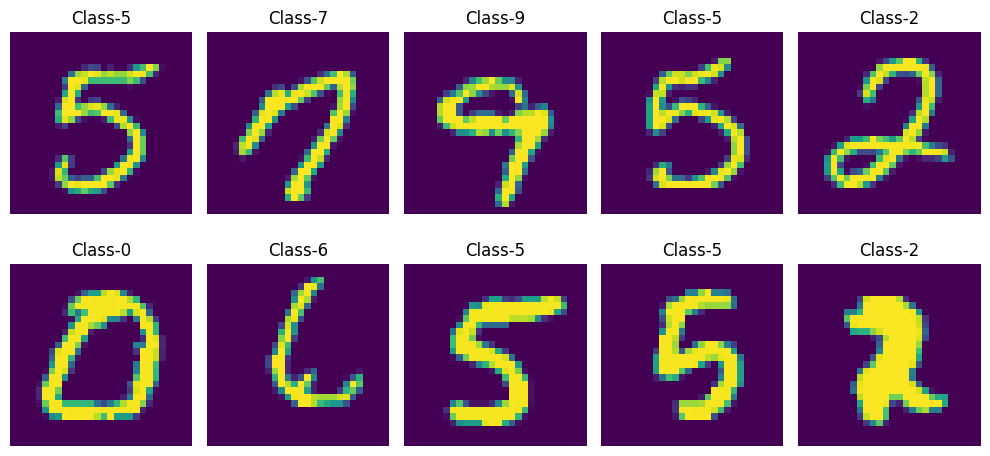

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28), cmap='viridis')
    ax.set_title(f'Class-{y_train.iloc[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

In [6]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=input_shape
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    units=10,
    activation='softmax'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.utils import to_categorical

y_train = df_train.iloc[:,0]
y_train = keras.utils.to_categorical(y_train, num_classes)


model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8149 - loss: 0.6652 - val_accuracy: 0.9312 - val_loss: 0.2372
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9509 - loss: 0.1687 - val_accuracy: 0.9542 - val_loss: 0.1454
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9676 - loss: 0.1082 - val_accuracy: 0.9665 - val_loss: 0.1085
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9751 - loss: 0.0823 - val_accuracy: 0.9740 - val_loss: 0.0840
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9801 - loss: 0.0665 - val_accuracy: 0.9722 - val_loss: 0.0841
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9836 - loss: 0.0547 - val_accuracy: 0.9768 - val_loss: 0.0728
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9852 - loss: 0.0470 - val_accuracy: 0.9778 - val_loss: 0.0688
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9864 - loss: 0.0441 - val_acc

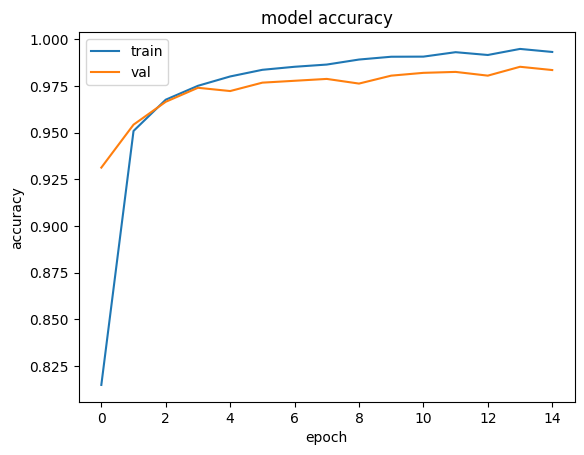

In [9]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

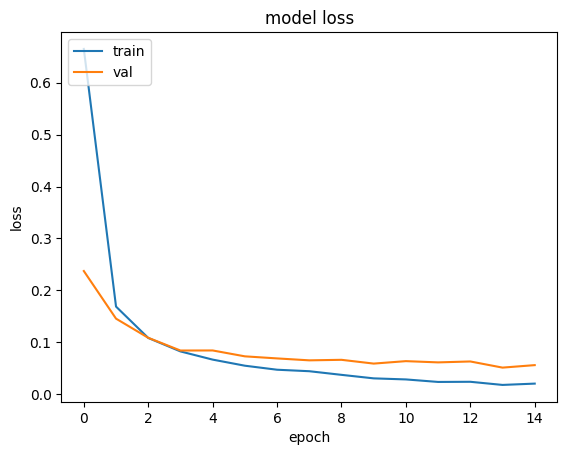

In [10]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

In [12]:
y_test_recomputed = df_test.iloc[:,0]
y_test_recomputed = keras.utils.to_categorical(y_test_recomputed, num_classes)

score = model.evaluate(
    X_test,
    y_test_recomputed,
    verbose=2
)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 5ms/step - accuracy: 0.9837 - loss: 0.0572
Test loss: 0.057238657027482986
Test accuracy: 0.9836983680725098


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[1.9372592e-07 7.9469831e-04 9.9920493e-01 1.6488733e-10 3.0570519e-18
  5.8432764e-14 1.4901779e-07 3.5779998e-17 3.6166576e-09 4.2842946e-19]]
2 0


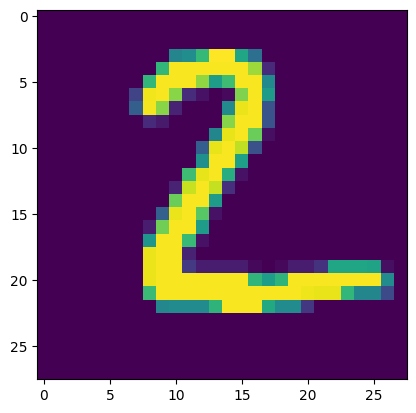

In [13]:
predict = model.predict(X_test[:1])

print(predict)
print(np.argmax(predict),
      np.argmax(y_test[0]))

plt.imshow(
    X_test[:1].reshape(28,28)
)

plt.show()

In [14]:
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[[2.0082345e-07 9.9922371e-01 1.0211027e-04 2.8584722e-07 3.5147573e-04
  3.1987733e-07 1.6312586e-06 2.8016409e-04 3.9450828e-05 6.4493128e-07]]
1 0


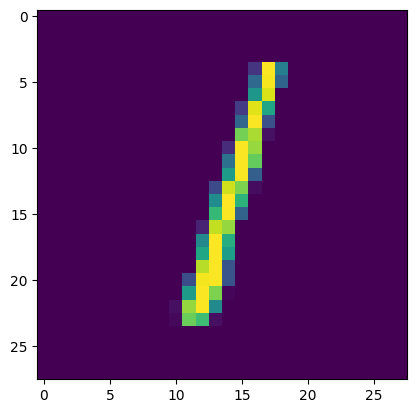

In [15]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=input_shape
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    units=10,
    activation='softmax'
))

model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])

print(predict)
print(np.argmax(predict),
      np.argmax(y_test[1]))

plt.imshow(
    X_test[1:2].reshape(28,28)
)

plt.show()

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


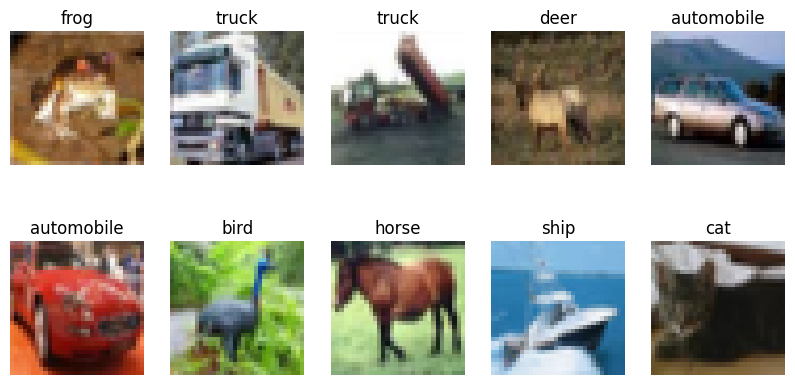

In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [5]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 10)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same',
                 activation='relu',
                 input_shape=(32,32,3)))
model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), padding='same',
                 activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), padding='same',
                 activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same',
                 activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), padding='same',
                 activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(128, (3,3), padding='same',
                 activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# FC
model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,13

 Total params: 1,343,018 (5.12 MB)

 Trainable params: 1,342,122 (5.12 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.3981 - loss: 1.7279 - val_accuracy: 0.2145 - val_loss: 2.9946
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5470 - loss: 1.2582 - val_accuracy: 0.5642 - val_loss: 1.2558
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6364 - loss: 1.0361 - val_accuracy: 0.6621 - val_loss: 0.9858
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6837 - loss: 0.9043 - val_accuracy: 0.7109 - val_loss: 0.8357
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7161 - loss: 0.8126 - val_accuracy: 0.7425 - val_loss: 0.7393
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7384 - loss: 0.7505 - val_accuracy: 0.7275 - val_loss: 0.8001
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7594 - loss: 0.6919 - val_accuracy: 0.7621 - val_loss: 0.6943
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7742 - loss: 0.6526 - val_acc

In [9]:
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", acc)

Test Accuracy: 0.7928000092506409


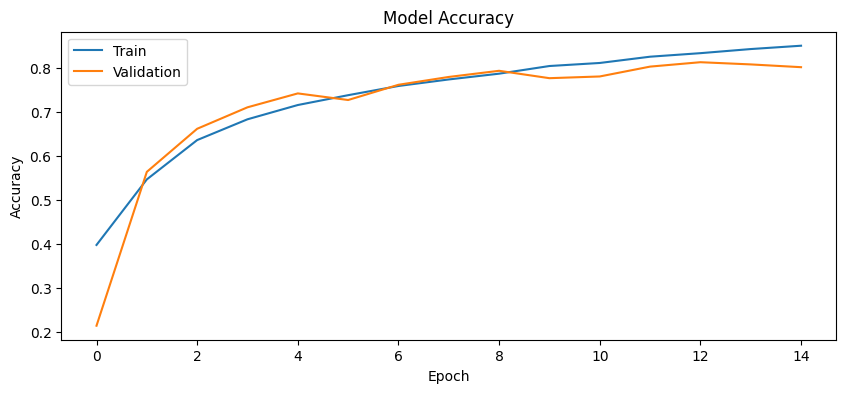

In [10]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

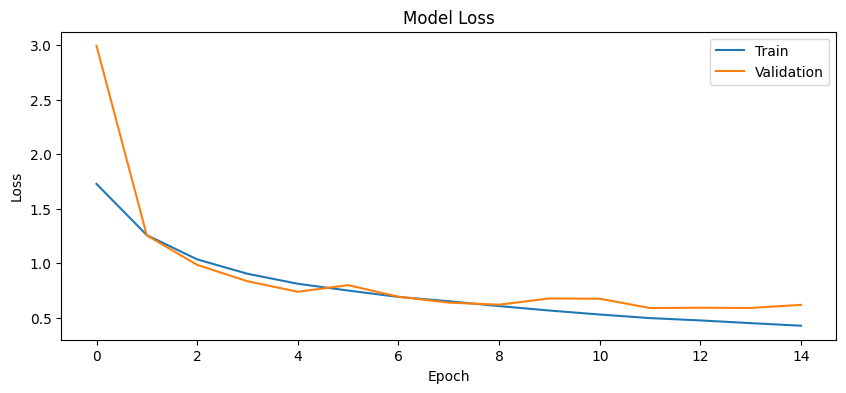

In [11]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [12]:
model.save('cifar10_cnn.keras')

Saving a0aJQEghN-ELRRfa6n-7zNy3cUw0Av-5520-6192-1755703061.webp to a0aJQEghN-ELRRfa6n-7zNy3cUw0Av-5520-6192-1755703061.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Class: cat


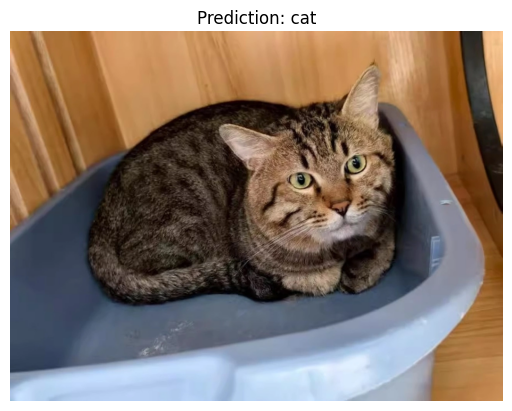

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
airplane    : 0.00%
automobile  : 0.00%
bird        : 0.00%
cat         : 97.95%
deer        : 0.00%
dog         : 1.04%
frog        : 1.00%
horse       : 0.00%
ship        : 0.00%
truck       : 0.00%


In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

uploaded = files.upload()


filename = list(uploaded.keys())[0]

img = image.load_img(
    filename,
    target_size=(32,32)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Class:", class_names[predicted_class])

plt.imshow(image.load_img(filename))
plt.title(
    f"Prediction: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()

prediction = model.predict(img_array)[0]

for i in range(10):
    print(
        f"{class_names[i]:12s}: {prediction[i]*100:.2f}%"
    )